# Trip O-D EDA
Understand demand patterns from origin-destination trip data.

**Sections:**
1. Setup
2. Basic stats & sparsity
3. Top routes
4. Round-trip vs point-to-point
5. Station departure profiles
6. Member vs casual route patterns

## 1. Setup

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from divvy_demand.infra.s3_client import S3Client

load_dotenv("../.env")
s3 = S3Client(env="prod")

trip = s3.read_processed("trip/all")
trip.head()

,date,start_station_name,start_station_id,end_station_name,end_station_id,total_rides,member_rides,casual_rides
0,2023-01-01,2112 W Peterson Ave,KA1504000155,Budlong Woods Library,15585,1,1,0
1,2023-01-01,2112 W Peterson Ave,KA1504000155,Warren Park East,RP-002,1,1,0
2,2023-01-01,900 W Harrison St,13028,May St & Taylor St,13160,1,0,1
3,2023-01-01,900 W Harrison St,13028,Morgan St & Polk St,TA1307000130,1,1,0
4,2023-01-01,Aberdeen St & Jackson Blvd,13157,Aberdeen St & Jackson Blvd,13157,1,1,0


In [79]:

trip["date"] = pd.to_datetime(trip["date"])
trip["is_roundtrip"] = trip["start_station_name"] == trip["end_station_name"]

print("Shape:", trip.shape)
trip.head()

Shape: (2962812, 9)


,date,start_station_name,start_station_id,end_station_name,end_station_id,total_rides,member_rides,casual_rides,is_roundtrip
0,2023-01-01,2112 W Peterson Ave,KA1504000155,Budlong Woods Library,15585,1,1,0,False
1,2023-01-01,2112 W Peterson Ave,KA1504000155,Warren Park East,RP-002,1,1,0,False
2,2023-01-01,900 W Harrison St,13028,May St & Taylor St,13160,1,0,1,False
3,2023-01-01,900 W Harrison St,13028,Morgan St & Polk St,TA1307000130,1,1,0,False
4,2023-01-01,Aberdeen St & Jackson Blvd,13157,Aberdeen St & Jackson Blvd,13157,1,1,0,True


## 2. Basic Stats & Sparsity

In [80]:
n_routes = trip[["start_station_name","end_station_name"]].drop_duplicates().shape[0]
n_stations = trip["start_station_name"].nunique()
n_days = trip["date"].nunique()
max_possible = n_stations * n_stations * n_days

print(f"Unique routes:        {n_routes:,}")
print(f"Unique stations:      {n_stations:,}")
print(f"Days:                 {n_days:,}")
print(f"Max possible O-D-day: {max_possible:,}")
print(f"Actual rows:          {len(trip):,}")
print(f"Sparsity:             {1 - len(trip)/max_possible:.2%}")

Unique routes:        171,172
Unique stations:      1,535
Days:                 366
Max possible O-D-day: 862,378,350
Actual rows:          2,962,812
Sparsity:             99.66%


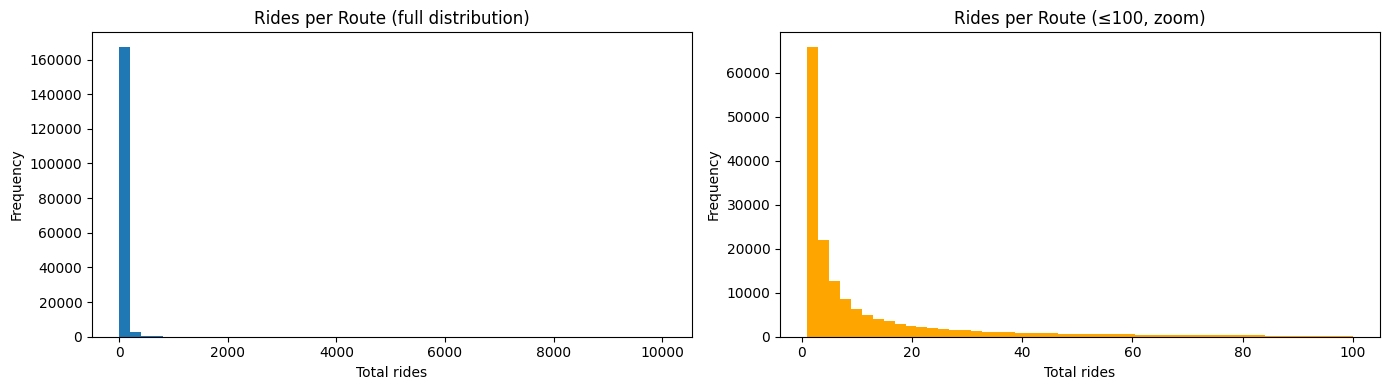

count    171172.000000
mean         25.322354
std          93.440631
min           1.000000
25%           1.000000
50%           4.000000
75%          17.000000
max       10046.000000
Name: total_rides, dtype: float64


In [81]:
# Distribution of rides per route (total across year)
route_totals = trip.groupby(["start_station_name","end_station_name"])["total_rides"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
route_totals.plot.hist(bins=50, ax=axes[0], title="Rides per Route (full distribution)")
axes[0].set_xlabel("Total rides")

route_totals[route_totals <= 100].plot.hist(bins=50, ax=axes[1], color="orange", title="Rides per Route (≤100, zoom)")
axes[1].set_xlabel("Total rides")
plt.tight_layout()
plt.show()

print(route_totals.describe())

Routes covering 80% of rides: 28,129 (16.4% of all routes)
Routes covering 90% of rides: 49,043 (28.7% of all routes)


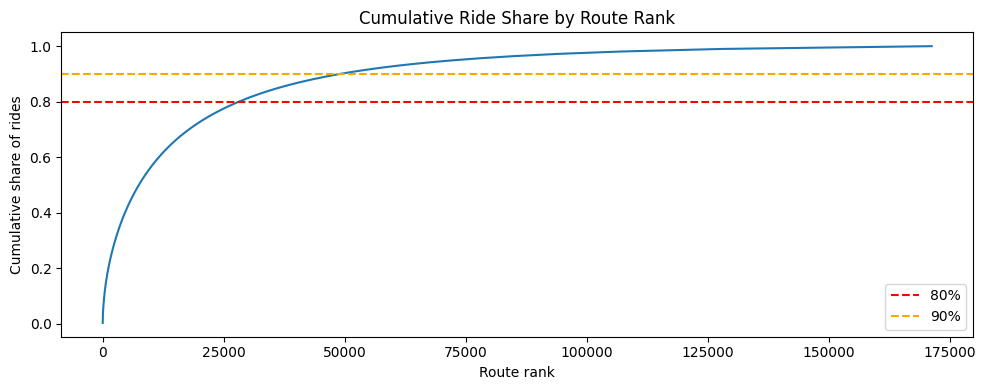

In [82]:
# How many routes account for 80% of total rides?
route_totals_sorted = route_totals.sort_values(ascending=False)
cumsum = route_totals_sorted.cumsum() / route_totals_sorted.sum()
n_80 = (cumsum <= 0.8).sum()
n_90 = (cumsum <= 0.9).sum()
print(f"Routes covering 80% of rides: {n_80:,} ({n_80/len(route_totals):.1%} of all routes)")
print(f"Routes covering 90% of rides: {n_90:,} ({n_90/len(route_totals):.1%} of all routes)")

plt.figure(figsize=(10, 4))
plt.plot(range(len(cumsum)), cumsum.values)
plt.axhline(0.8, color="red", linestyle="--", label="80%")
plt.axhline(0.9, color="orange", linestyle="--", label="90%")
plt.xlabel("Route rank")
plt.ylabel("Cumulative share of rides")
plt.title("Cumulative Ride Share by Route Rank")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Top Routes

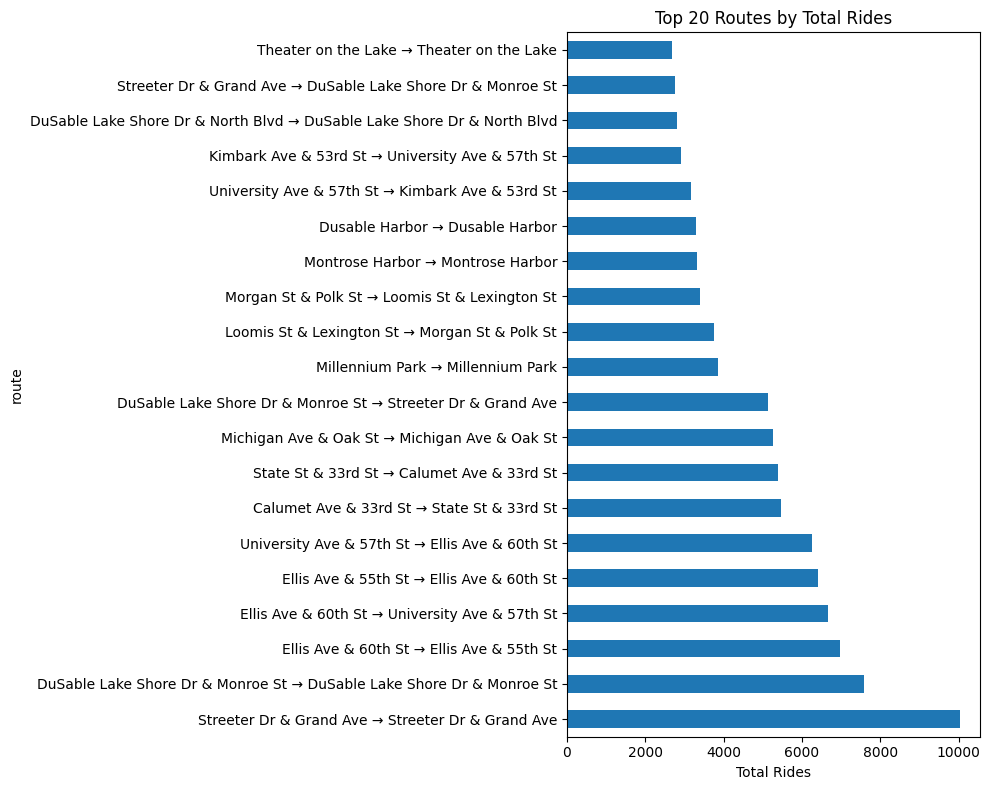

In [83]:
top_routes = route_totals.sort_values(ascending=False).head(20).reset_index()
top_routes["route"] = top_routes["start_station_name"] + " → " + top_routes["end_station_name"]
top_routes.set_index("route")["total_rides"].plot.barh(figsize=(10, 8), title="Top 20 Routes by Total Rides")
plt.xlabel("Total Rides")
plt.tight_layout()
plt.show()

## 4. Round-Trip vs Point-to-Point

In [84]:
rt = trip.groupby("is_roundtrip")["total_rides"].agg(["sum","count"]).rename(index={True:"Round-trip", False:"Point-to-point"})
rt["rides_pct"] = (rt["sum"] / rt["sum"].sum() * 100).round(1)
rt["routes_pct"] = (rt["count"] / rt["count"].sum() * 100).round(1)
rt.columns = ["total_rides", "route_days", "rides_%", "route_days_%"]
print(rt)

                total_rides  route_days  rides_%  route_days_%
is_roundtrip                                                  
Point-to-point      4058234     2861829     93.6          96.6
Round-trip           276244      100983      6.4           3.4


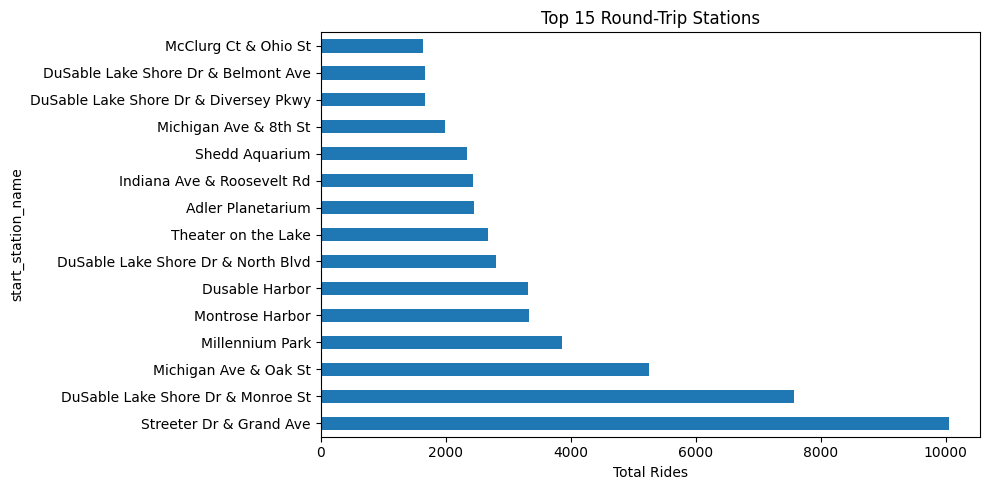

In [85]:
# Top round-trip stations
rt_stations = (
    trip[trip["is_roundtrip"]]
    .groupby("start_station_name")["total_rides"].sum()
    .sort_values(ascending=False)
    .head(15)
)
rt_stations.plot.barh(figsize=(10, 5), title="Top 15 Round-Trip Stations")
plt.xlabel("Total Rides")
plt.tight_layout()
plt.show()

## 5. Station Departure Profiles

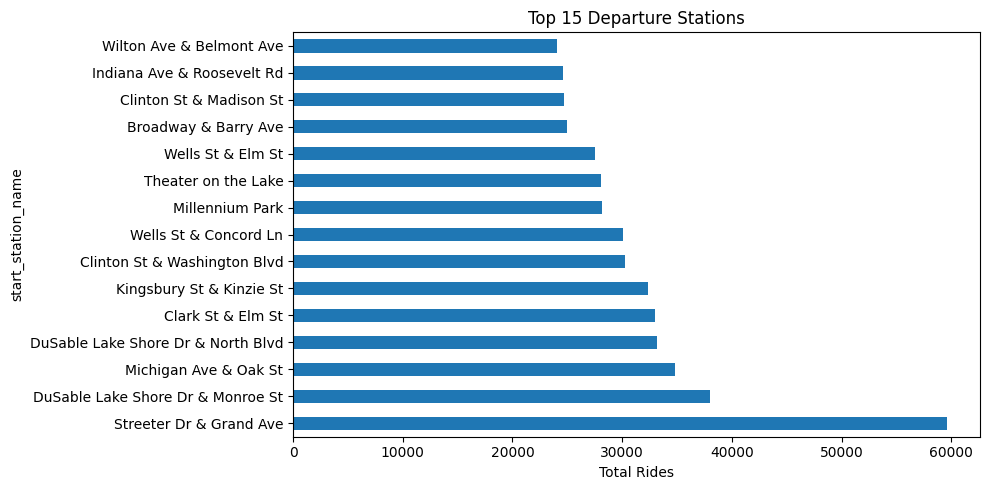

In [86]:
# Top departure stations
top_departures = trip.groupby("start_station_name")["total_rides"].sum().sort_values(ascending=False).head(15)
top_departures.plot.barh(figsize=(10, 5), title="Top 15 Departure Stations")
plt.xlabel("Total Rides")
plt.tight_layout()
plt.show()

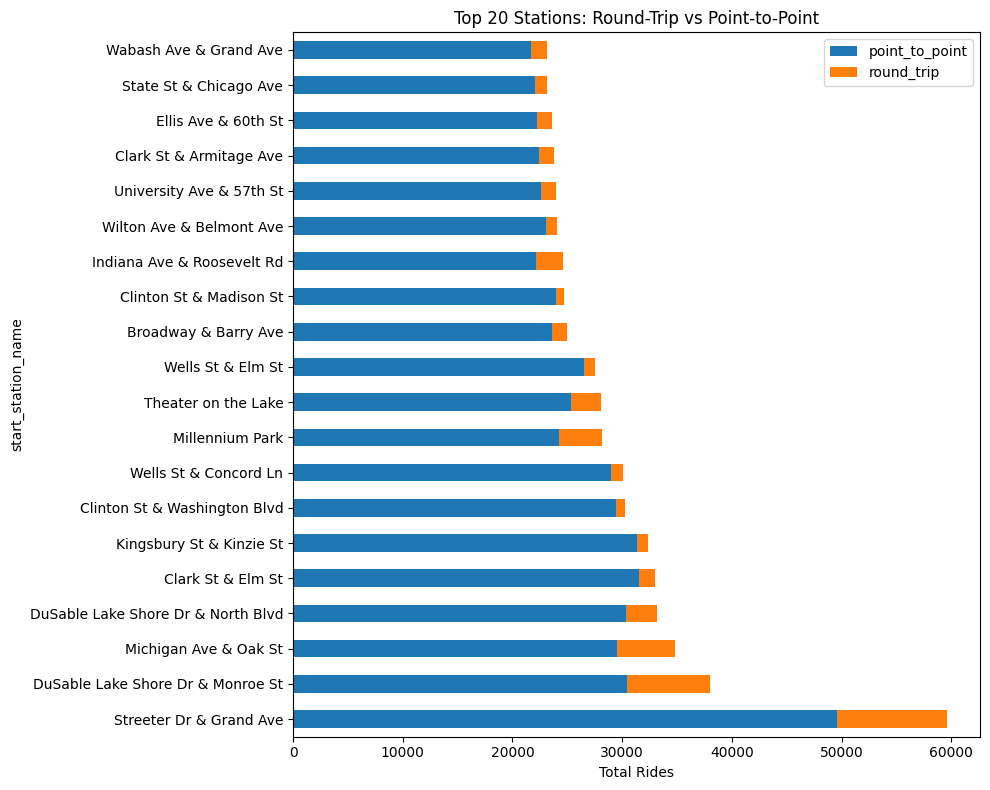

In [87]:
# For top stations: what % of their rides are round-trips?
station_rt = trip.groupby(["start_station_name","is_roundtrip"])["total_rides"].sum().unstack(fill_value=0)
station_rt.columns = ["point_to_point","round_trip"]
station_rt["rt_pct"] = station_rt["round_trip"] / (station_rt["round_trip"] + station_rt["point_to_point"])
station_rt["total"] = station_rt["round_trip"] + station_rt["point_to_point"]

top = station_rt.sort_values("total", ascending=False).head(20)
top[["point_to_point","round_trip"]].plot.barh(stacked=True, figsize=(10, 8), title="Top 20 Stations: Round-Trip vs Point-to-Point")
plt.xlabel("Total Rides")
plt.tight_layout()
plt.show()

## 6. Member vs Casual Route Patterns

In [88]:
# Member vs casual split by route type
trip["member_pct"] = trip["member_rides"] / trip["total_rides"]
print("Member % on round-trips vs point-to-point:")
print(trip.groupby("is_roundtrip")["member_pct"].mean().rename({True:"Round-trip", False:"Point-to-point"}).round(3))

Member % on round-trips vs point-to-point:
is_roundtrip
Point-to-point    0.691
Round-trip        0.554
Name: member_pct, dtype: float64


In [89]:
# Top casual routes (likely tourist)
casual_routes = trip.groupby(["start_station_name","end_station_name"])["casual_rides"].sum().sort_values(ascending=False).head(10).reset_index()
casual_routes["route"] = casual_routes["start_station_name"] + " → " + casual_routes["end_station_name"]
print("Top 10 Casual Routes:")
casual_routes[["route","casual_rides"]]

Top 10 Casual Routes:


,route,casual_rides
0,Streeter Dr & Grand Ave → Streeter Dr & Grand Ave,8653
1,DuSable Lake Shore Dr & Monroe St → DuSable La...,6740
2,DuSable Lake Shore Dr & Monroe St → Streeter D...,4628
3,Michigan Ave & Oak St → Michigan Ave & Oak St,4261
4,Millennium Park → Millennium Park,3431
5,Dusable Harbor → Dusable Harbor,2799
6,Montrose Harbor → Montrose Harbor,2529
7,Streeter Dr & Grand Ave → DuSable Lake Shore D...,2352
8,DuSable Lake Shore Dr & North Blvd → DuSable L...,2044
9,Ellis Ave & 60th St → Ellis Ave & 55th St,2037


In [90]:
# Top member routes (likely commute)
member_routes = trip.groupby(["start_station_name","end_station_name"])["member_rides"].sum().sort_values(ascending=False).head(10).reset_index()
member_routes["route"] = member_routes["start_station_name"] + " → " + member_routes["end_station_name"]
print("Top 10 Member Routes:")
member_routes[["route","member_rides"]]

Top 10 Member Routes:


,route,member_rides
0,Ellis Ave & 60th St → University Ave & 57th St,5208
1,Calumet Ave & 33rd St → State St & 33rd St,5204
2,State St & 33rd St → Calumet Ave & 33rd St,5149
3,University Ave & 57th St → Ellis Ave & 60th St,4935
4,Ellis Ave & 60th St → Ellis Ave & 55th St,4930
5,Ellis Ave & 55th St → Ellis Ave & 60th St,4525
6,Loomis St & Lexington St → Morgan St & Polk St,3445
7,Morgan St & Polk St → Loomis St & Lexington St,3163
8,MLK Jr Dr & 29th St → State St & 33rd St,2528
9,State St & 33rd St → MLK Jr Dr & 29th St,2448


## 7. Coverage Effect: Routes Active All 365 Days

Total routes: 171,172
Total rides:  4,334,478
Days in dataset: 366


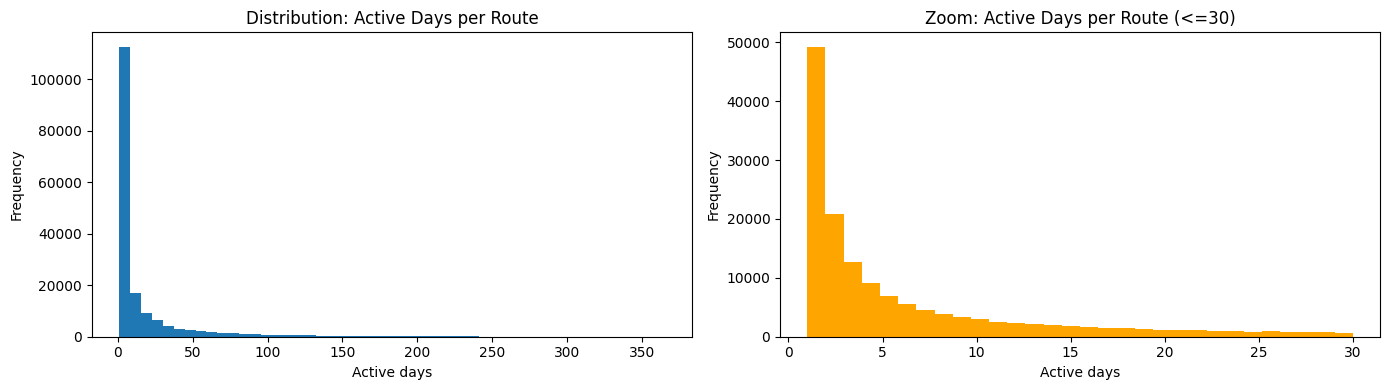


Route active-day percentiles:
count    171172.0
mean         17.3
std          35.4
min           1.0
50%           4.0
75%          15.0
90%          48.0
95%          86.0
99%         184.0
max         365.0
Name: active_days, dtype: float64


In [91]:
# Count distinct days each route appears
route_days = (
    trip.groupby(["start_station_name", "end_station_name"])["date"]
    .nunique()
    .rename("active_days")
)

total_rides_all = trip["total_rides"].sum()
total_routes_all = len(route_days)

print(f"Total routes: {total_routes_all:,}")
print(f"Total rides:  {total_rides_all:,}")
print(f"Days in dataset: {trip['date'].nunique()}")

# Distribution of active days per route
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
route_days.plot.hist(bins=50, ax=axes[0], title="Distribution: Active Days per Route")
axes[0].set_xlabel("Active days")
route_days[route_days <= 30].plot.hist(bins=30, ax=axes[1], color="orange",
                                        title="Zoom: Active Days per Route (<=30)")
axes[1].set_xlabel("Active days")
plt.tight_layout()
plt.show()

print("\nRoute active-day percentiles:")
print(route_days.describe(percentiles=[.5, .75, .9, .95, .99]).round(1))

In [92]:
# Sweep thresholds: for each min_days cutoff, how many routes remain and what % of rides do they cover?
thresholds = [1, 30, 60, 90, 120, 180, 240, 300, 330, 350, 360, 365]

trip_indexed = trip.copy()
trip_indexed["route"] = list(zip(trip_indexed["start_station_name"], trip_indexed["end_station_name"]))
route_ride_totals = trip_indexed.groupby("route")["total_rides"].sum()

rows = []
for t in thresholds:
    kept = route_days[route_days >= t].index  # MultiIndex of (start, end) tuples
    kept_set = set(kept)
    rides_covered = route_ride_totals[route_ride_totals.index.isin(kept_set)].sum()
    rows.append({
        "min_days": t,
        "routes_kept": len(kept),
        "routes_pct": len(kept) / total_routes_all * 100,
        "rides_covered": rides_covered,
        "rides_pct": rides_covered / total_rides_all * 100,
    })

coverage = pd.DataFrame(rows)
print(coverage.to_string(index=False, float_format="%.1f"))

 min_days  routes_kept  routes_pct  rides_covered  rides_pct
        1       171172       100.0        4334478      100.0
       30        26397        15.4        3404730       78.5
       60        13754         8.0        2763183       63.7
       90         8132         4.8        2226320       51.4
      120         4979         2.9        1773913       40.9
      180         1853         1.1        1073179       24.8
      240          654         0.4         604003       13.9
      300          160         0.1         254524        5.9
      330           39         0.0          96216        2.2
      350           13         0.0          48802        1.1
      360            2         0.0          10854        0.3
      365            2         0.0          10854        0.3


 min_days  routes_kept  routes_pct  rides_covered  rides_pct
        1       171172       100.0        4334478      100.0
       30        26397        15.4        3404730       78.5
       60        13754         8.0        2763183       63.7
       90         8132         4.8        2226320       51.4
      120         4979         2.9        1773913       40.9
      180         1853         1.1        1073179       24.8
      240          654         0.4         604003       13.9
      300          160         0.1         254524        5.9
      330           39         0.0          96216        2.2
      350           13         0.0          48802        1.1
      360            2         0.0          10854        0.3
      365            2         0.0          10854        0.3


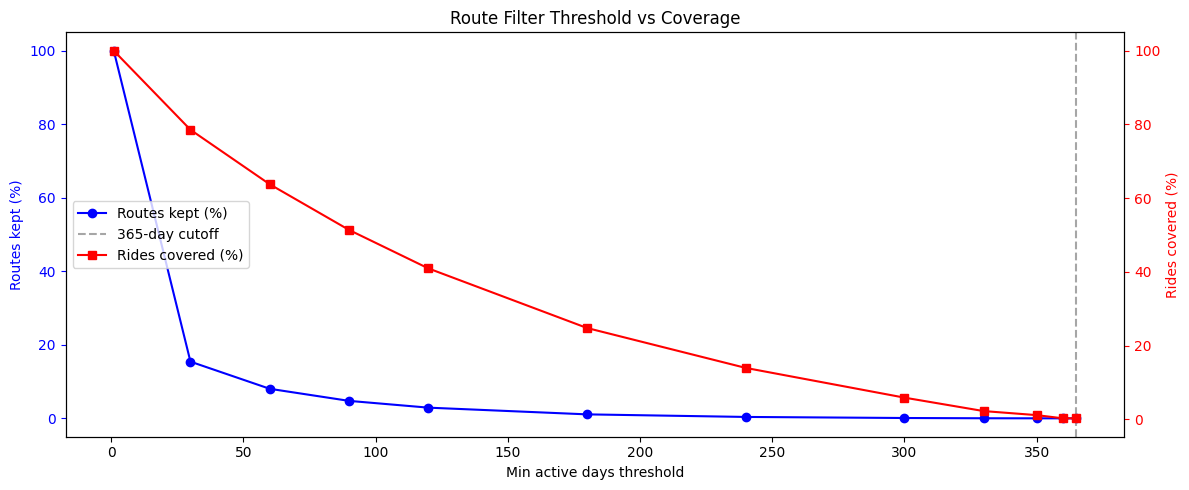


At 365-day threshold:
  Routes kept:   2 (0.0% of all routes)
  Rides covered: 10,854 (0.3% of all rides)


In [93]:
# Dual-axis: routes kept % vs rides covered % across thresholds
thresholds = [1, 30, 60, 90, 120, 180, 240, 300, 330, 350, 360, 365]

trip_indexed = trip.copy()
trip_indexed["route"] = list(zip(trip_indexed["start_station_name"], trip_indexed["end_station_name"]))
route_ride_totals = trip_indexed.groupby("route")["total_rides"].sum()

total_rides_all = trip["total_rides"].sum()
total_routes_all = len(route_days)

rows = []
for t in thresholds:
    kept = route_days[route_days >= t].index
    kept_set = set(kept)
    rides_covered = route_ride_totals[route_ride_totals.index.isin(kept_set)].sum()
    rows.append({
        "min_days": t,
        "routes_kept": len(kept),
        "routes_pct": len(kept) / total_routes_all * 100,
        "rides_covered": rides_covered,
        "rides_pct": rides_covered / total_rides_all * 100,
    })

coverage = pd.DataFrame(rows)
print(coverage.to_string(index=False, float_format="%.1f"))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.plot(coverage["min_days"], coverage["routes_pct"], "b-o", label="Routes kept (%)")
ax2.plot(coverage["min_days"], coverage["rides_pct"], "r-s", label="Rides covered (%)")
ax1.axvline(365, color="gray", linestyle="--", alpha=0.7, label="365-day cutoff")
ax1.set_xlabel("Min active days threshold")
ax1.set_ylabel("Routes kept (%)", color="blue")
ax2.set_ylabel("Rides covered (%)", color="red")
ax1.tick_params(axis="y", colors="blue")
ax2.tick_params(axis="y", colors="red")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left")
plt.title("Route Filter Threshold vs Coverage")
plt.tight_layout()
plt.show()

row_365 = coverage[coverage["min_days"] == 365].iloc[0]
print(f"\nAt 365-day threshold:")
print(f"  Routes kept:   {int(row_365['routes_kept']):,} ({row_365['routes_pct']:.1f}% of all routes)")
print(f"  Rides covered: {int(row_365['rides_covered']):,} ({row_365['rides_pct']:.1f}% of all rides)")

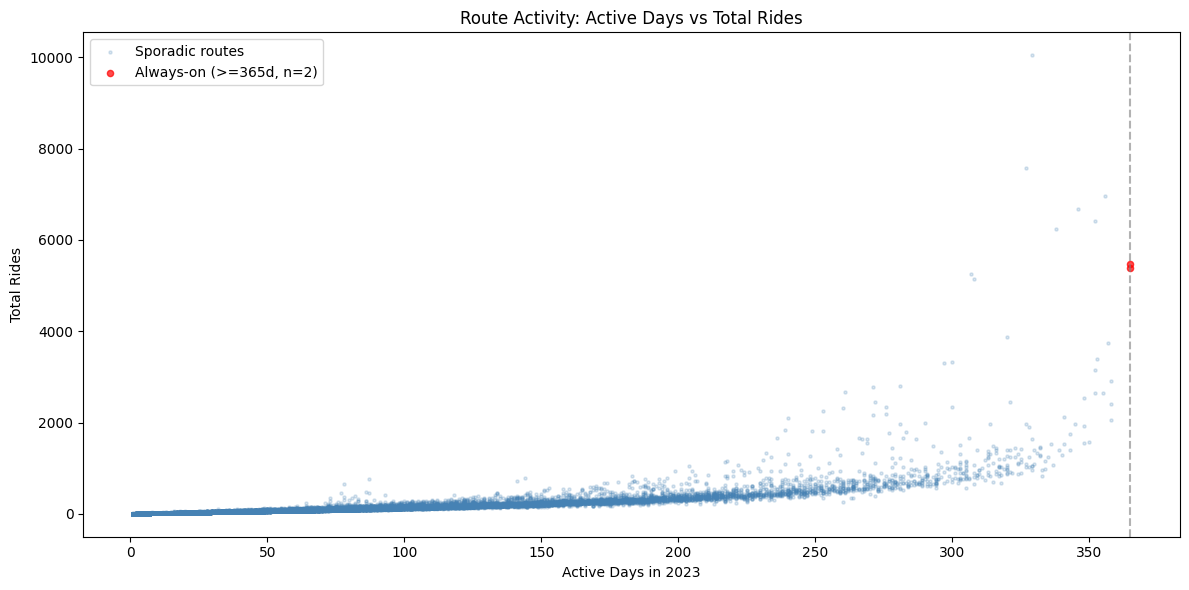

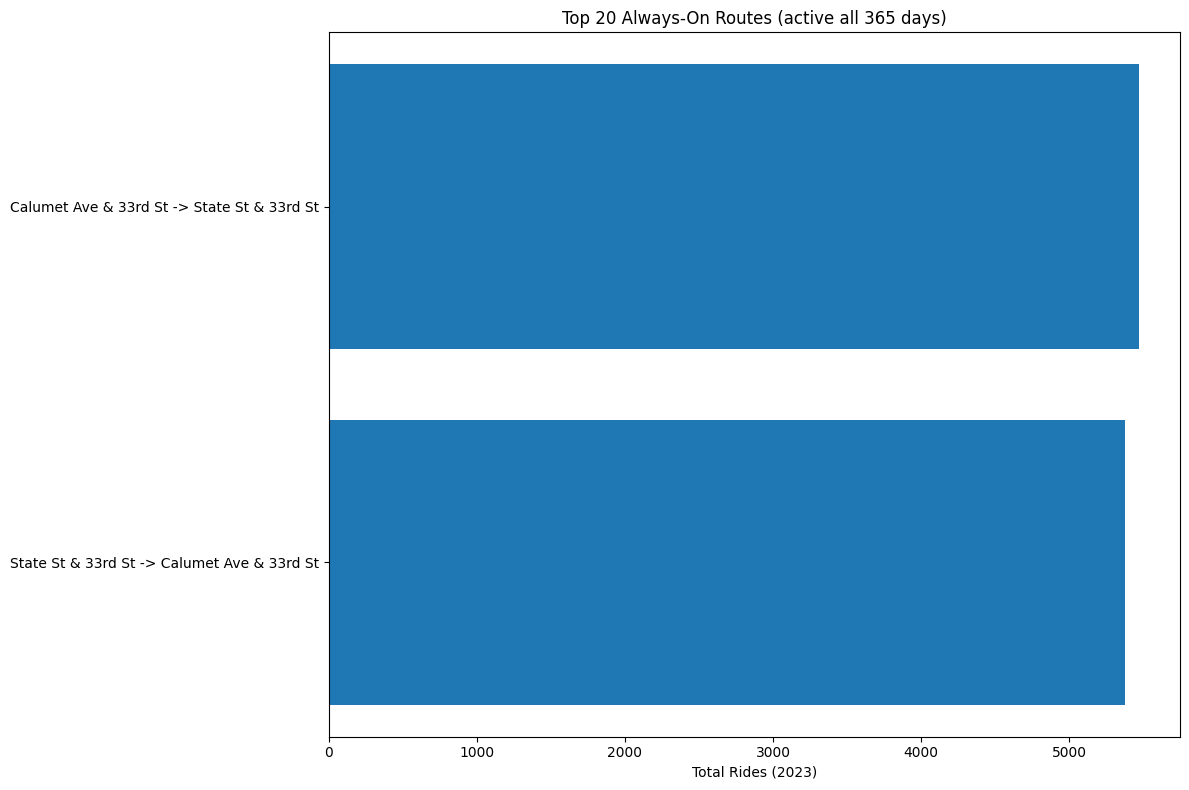

In [94]:
# Scatter: active days vs total rides — always-on routes highlighted
route_profile = pd.DataFrame({
    "active_days": route_days,
    "total_rides": route_ride_totals,
})
always_on_mask = route_profile["active_days"] >= 365

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    route_profile.loc[~always_on_mask, "active_days"],
    route_profile.loc[~always_on_mask, "total_rides"],
    s=5, alpha=0.2, color="steelblue", label="Sporadic routes"
)
ax.scatter(
    route_profile.loc[always_on_mask, "active_days"],
    route_profile.loc[always_on_mask, "total_rides"],
    s=20, alpha=0.7, color="red", label=f"Always-on (>=365d, n={always_on_mask.sum():,})"
)
ax.axvline(365, color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("Active Days in 2023")
ax.set_ylabel("Total Rides")
ax.set_title("Route Activity: Active Days vs Total Rides")
ax.legend()
plt.tight_layout()
plt.show()

# Top 20 always-on routes
always_on_rides = route_ride_totals[route_ride_totals.index.isin(set(route_days[route_days >= 365].index))].sort_values(ascending=False)
top_always_on = always_on_rides.head(20).reset_index()
top_always_on["route"] = top_always_on["route"].apply(lambda x: f"{x[0]} -> {x[1]}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_always_on["route"][::-1], top_always_on["total_rides"][::-1])
ax.set_xlabel("Total Rides (2023)")
ax.set_title(f"Top 20 Always-On Routes (active all 365 days)")
plt.tight_layout()
plt.show()